# Problem set 5: Adiabatic state preparation

Due on Tuesday, 14.05.2025

This notebook has been adapted from a Tutorial by J. R. Johansson (robert@riken.jp), http://dml.riken.jp/~rob/

## Introduction

In adiabatic quantum computing, the system is initialized in the easy-to-prepare ground state of a Hamiltonian $H_0$, and then the Hamiltonian is gradually transformed into $H_1$, which is constructed in such a way that the groundstate of $H_1$ encodes the solution to a difficult problem. The transformation of $H_0$ to $H_1$ can for example be written in the form

$\displaystyle H(t) = (1-\lambda(t)) H_0 + \lambda(t) H_1$

where $\lambda(t)$ is a function that goes from goes from $0$ to $1$ when $t$ goes from $0$ to $t_{\rm final}$.

If this gradual tranformation is slow enough (satisfying the adiabicity critera), the evolution of the system will remain in its ground state.

If the Hamiltonian is transformed from $H_0$ to $H_1$ too quickly, the system will get excited from the ground state and the adiabatic computing algorithm fails.

In this notebook we explore the dynamics of a spin Hamiltonian that is transformed from a simple Hamiltonian with an easy to prepare ground state, into a Hamiltonian with a strongly-correlated antiferromagnetic ground state.

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np  
# from numpy import * 
from qutip import *

## Exercise 1: Setting up the system

Consider the Hamiltonians
$$
H_0 = -\sum_{i=1}^N \sigma^x_i
$$
and
$$
H_1 = \frac{1}{2}\sum_{i=1}^{N-1} J_z \sigma^z_i\sigma^z_{i+1} - \frac{1}{2}\sum_{i=1}^{N} h \sigma^z_i
$$
with $J_z=2\pi$ and $h=0.5\cdot 2\pi$.

Build the matrix representation of $H_0$ and $H_1$ and the initial state vector $|\psi(0)\rangle=\left[(|0\rangle+|1\rangle)/\sqrt{2}\right]^{\otimes N}$. Use a small $N$ to check the correctness of your code manually. As a first step, you may want to use the function buildSparseGateSingle(n, i, gate) from exercise sheet 3 to build the matrix representations of single qubit Pauli operators acting on an $N$-qubit system.


### Precalculate operators

In [35]:
# pre-allocate operators
si = qeye(2) # identity
sx = sigmax()
sy = sigmay()
sz = sigmaz()

# This is basically the same as the function
# buildSparseGateSingle(n, i, gate) from exercise sheet 3.
def sx_list(N):
    sx_list_flag = []
    for n in range(N):
        op_list = []
        for m in range(N):
            op_list.append(si)
        op_list[n] = sx
        sx_list_flag.append(tensor(op_list))
    return(sx_list_flag)

def sy_list(N):
    # complete here
    return(sy_list_flag)

def sz_list(N):
    # complete here
    return(sz_list_flag)

### Construct the initial state

In [6]:
# Construct the initial state with all spins aligned along x
# which coincides with the ground state for H0
ket0 = 1/np.sqrt(2)*basis(2,0) + 1/np.sqrt(2)*basis(2,1) 

def psi0(N):
    psi0_flag = tensor([ket0 for n in range(N)])
    return(psi0_flag)

print(ket0)

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]


### Construct the Hamiltonian

In [22]:
# Construct the trivial Hamiltonian
def H0(N):
    H0_flag = 0    
    for n in range(N):
        H0_flag += - sx_list(N)[n]
    return(H0_flag)

# Construct the problem Hamiltonian
def H1(N):
    # complete here
    return(H1_flag)

## Exercise 2: Instantaneous eigenstates

Using $N=5$ and $\lambda(t)=t/t_{\rm final}$ with $t_{\rm final}=50$, calculate the eigenvalues and eigenstates of $H(t)$ for a grid of 100 points between $t=0$ and $t_{\rm final}$ and plot the lowest 20 eigenenergies as a function of time.

Also calculate the overlap of instantaneous ground state with the initial state and with the ground state of $H_1$ as a function of time. You should see how the character of the state changes gradually from one to the other. At the point where the excitation gap is smallest this change should be the fastest.

In [8]:
# define function for H(t)
def H_t(t, H0, H1, N):
    H_at_t = (1-t/taumax)*H0(N) + (t/taumax)*H1(N)
    return H_at_t

In [9]:
# compute the ground state of H1
def psiH1(N):
    # complete here
    return psiH1_flag

### Eigenspectrum of $H(t)$ for $N=5$

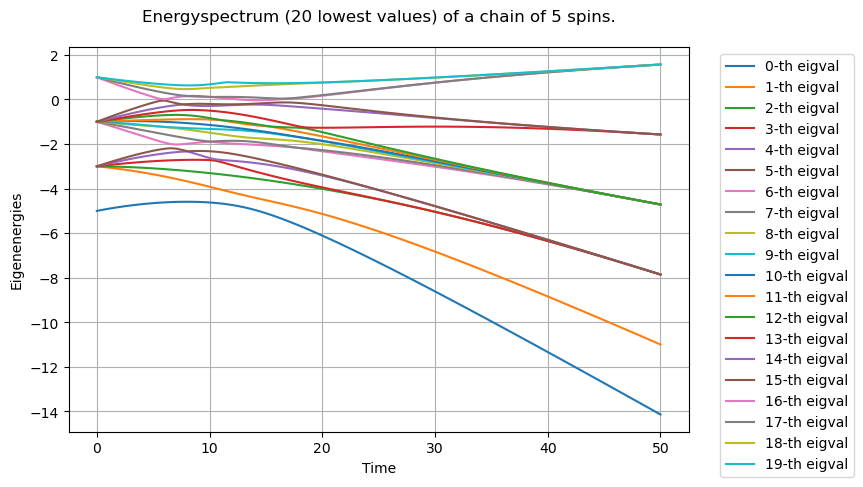

In [24]:
Nspin = 5 # number of spins
M = 20  # number of eigenenergies to plot

# storage for eigenvalues
eig_energy_list = []

# total time of the sweep increase taumax to make the sweep more adiabatic
taumax = 50.0
taulist = np.linspace(0, taumax, 100) # plot for 100 steps

for t in taulist:
    H = H_t(t,H0,H1,Nspin)
    # complete here: compute first 20 eigenvalues

# complete here: plot the result!

### Instantaneous ground state of $H(t)$

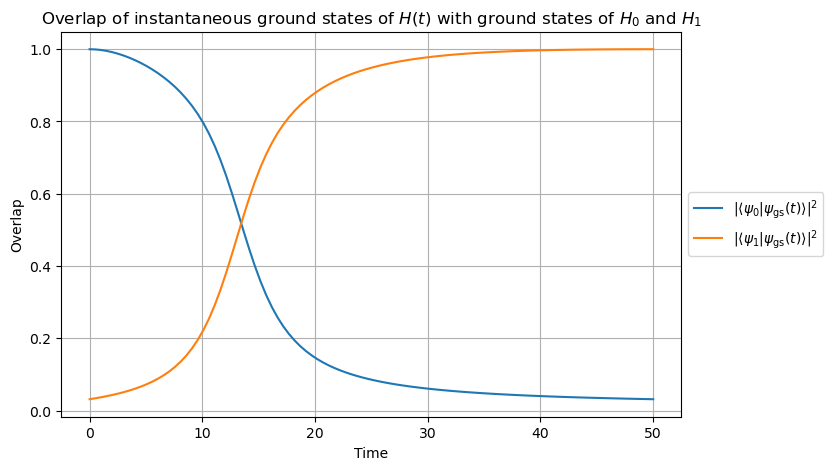

In [25]:
# compute the instantaneous ground state of H(t)
Nspin = 5 # number of spins
# total time of the sweep - increase taumax to make the sweep more adiabatic
taumax = 50.0
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1
psi0_N = psi0(Nspin)
psiH1_N = psiH1(Nspin)

overlaps_psi0 = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1 = [] # storage for overlaps with H1

# loop over time to compute ground state and overlap with psi0 and psiH1
for t in taulist:
    # complete here

# complete here: plot the result!

### Instantaneous excited states of $H(t)$

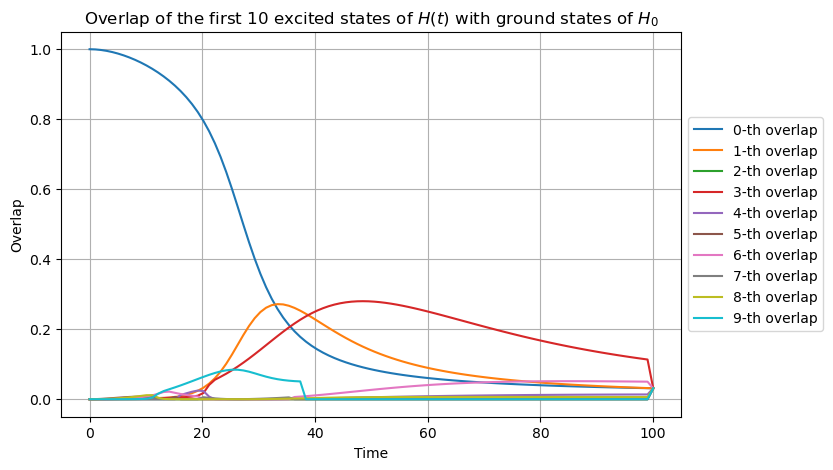

In [43]:
# compute instantaneous excited states of H(t)
Nspin = 5 # number of spins
M = 10  # number of eigenenergies to plot
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

psi0_N = psi0(Nspin) # ground states of H0
overlaps_psi0_list = [] # storage for overlaps with H0 (initial ground state)

for t in taulist:
    H = H_t(t, H0, H1, Nspin)
    _, eigenvectors = H.eigenstates()
    # complete here

# complete here: plot the result!

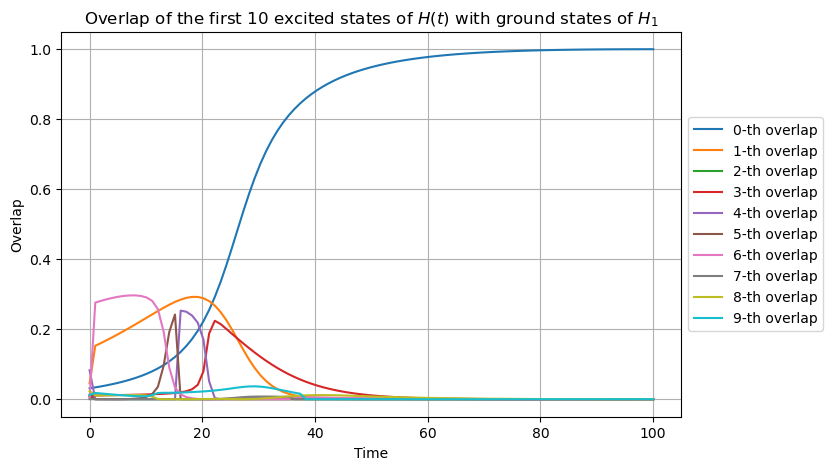

In [42]:
# compute instantaneous excited states of H(t)
Nspin = 5 # number of spins
M = 10  # number of eigenenergies to plot
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

psiH1_N = psiH1(Nspin) # ground states of H1
overlaps_psiH1_list = [] # storage for overlaps with H1

for t in taulist:
    H = H_t(t, H0, H1, Nspin)
    _, eigenvectors = H.eigenstates()
    # complete here

# complete here: plot the result!

## Exercise 3: Time evolution

Simulate the time evolution under $H(t)$ using the parameters given above. You can use the qutip function mesolve(), which allows you to solve the time-dependent Schrödinger equation. (see https://qutip.org/docs/latest/apidoc/functions.html#module-qutip.mesolve)

Calculate the overlap of the obtained $|\psi(t)\rangle$ with the instantaneous eigenstates and plot them as a function of time. Try this for different values of $t_{\rm final}$ and interpret your results.

Compare results for an odd number of qubits to an even number of qubits (i.e N=5 vs N=6). What causes the difference?

### Evolve the system in time

In [28]:
# Understand the following function for the time-evolution of the state
def psi_te(N, tlist): # 'te' stays for time-evolved (with Schrödinger's equation)
    args = {'t_max': max(tlist)}
    
    # construct the time-dependent Hamiltonian
    # in list-function format (which can be used as input for mesolve())
    h_t_flag = [[H0(N), lambda t, args : (args['t_max']-t)/args['t_max']],
       [H1(N), lambda t, args : t/args['t_max']]]
    
    # evolve the system, request the solver to call process_rho at each time step.
    result_flag = mesolve(h_t_flag, psi0(N), tlist, [], [], args)
    
    # resolve time-dependent Schrödinger's equation
    psi_te_flag = result_flag.states 
    return(psi_te_flag)

### Evolvution for $N=5$ and $t_{\text{max}}=50$

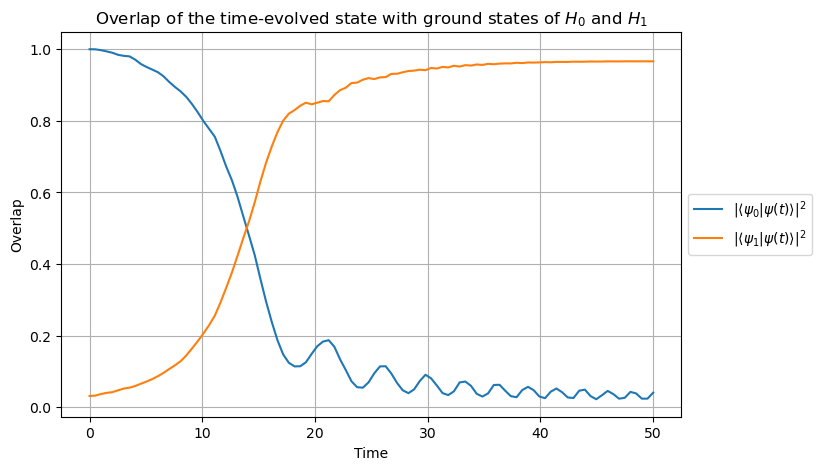

In [31]:
Nspin = 5
taumax = 50.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1 for Nspin
psi0_N = psi0(Nspin)
psiH1_N = psiH1(Nspin)

# compute the time-evolved state for Nspin
psi_te_N = psi_te(Nspin, taulist)

overlaps_psi0_te = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1_te = [] # storage for overlaps with H1

# loop over time to compute overlap with psi0 and psiH1
for t in range(len(taulist)):
    # complete here

# complete here: plot the result!

### Evolvution for $N=5$ and $t_{\text{max}}=100$

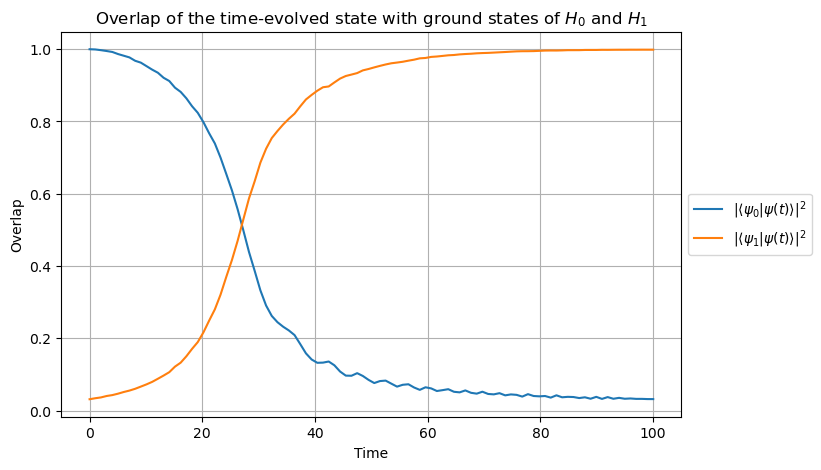

In [32]:
Nspin = 5
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1 for Nspin
psi0_N = psi0(Nspin)
psiH1_N = psiH1(Nspin)

# compute the time-evolved state for Nspin
psi_te_N = psi_te(Nspin, taulist)

overlaps_psi0_te = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1_te = [] # storage for overlaps with H1

# loop over time to compute overlap with psi0 and psiH1
for t in range(len(taulist)):
    # complete here

# complete here: plot the result!

### Evolvution for $N=6$ and $t_{\text{max}}=100$

What changes for N=6?

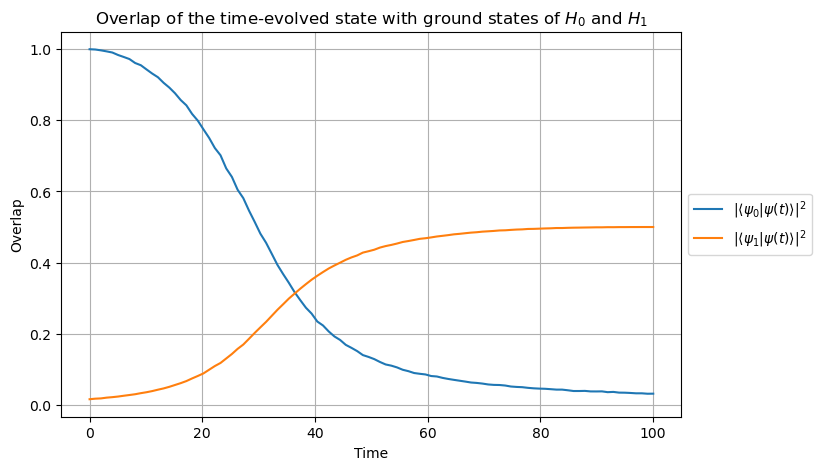

In [33]:
Nspin = 6
taumax = 100.0 # total time of the sweep
taulist = np.linspace(0, taumax, 100) 

# ground states of H0 and H1 for Nspin
psi0_N = psi0(Nspin)
psiH1_N = psiH1(Nspin)

# compute the time-evolved state for Nspin
psi_te_N = psi_te(Nspin, taulist)

overlaps_psi0_te = [] # storage for overlaps with H0 (initial ground state)
overlaps_psiH1_te = [] # storage for overlaps with H1

# loop over time to compute overlap with psi0 and PsiH1
for t in range(len(taulist)):
    # complete here

# complete here: plot the result!